### Подготовка

In [3]:
from torchvision import datasets
import torchvision.transforms as transforms
import torch.optim as optim
import time

In [4]:
from classification_utils import *
from cifar_models import CNN6
from quantized_layers import *
from model_saving import *

In [5]:
transformer_train = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(9),
        transforms.RandomCrop(32, 4),
        transforms.ToTensor(),
])
transformer_test = transforms.Compose([
        transforms.ToTensor(),
])

DATA_PATH = './data'
BATCH_SIZE = 100

train_set = datasets.CIFAR10(DATA_PATH, train=True, transform=transformer_train, download=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_set = datasets.CIFAR10(DATA_PATH, train=False, transform=transformer_test, download=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
def ptq_model(model, in_bins: int, w_bins: int, symmetric_mode: bool,
              train_loader, device='cpu', mode='ada'):
    model = model.to(device)
    qmodel = CNN6()
    qmodel.load_state_dict(model.state_dict())
    qmodel = qmodel.to(device)

    cmodel = CNN6()
    cmodel.load_state_dict(model.state_dict())
    cmodel = cmodel.to(device)
    N_BLOCKS = 50

    cache = []
    for i, (X, _) in enumerate(train_loader):
        if i == N_BLOCKS:
            break
        cache.append(X.to(device))
        cmodel.cache(X.to(device))

    in_step = -1
    for i, layer_name in enumerate(qmodel.layer_iterator()):
        layer = getattr(cmodel, layer_name)
        corrected_in = None
        if i > 0:
            for X in cache:
                qmodel.cache(X)
            prev_layer = getattr(qmodel, layer_name)
            corrected_in = prev_layer.cached_in
        qlayer = QConv2d(layer, in_bins, w_bins, symmetric_mode, in_step, mode, corrected_in).to(device)
        in_step = qlayer.input_quant.scale * qlayer.weight_quant.scale
        setattr(qmodel, layer_name, qlayer)
        qmodel.drop_cache()
    del cmodel
    return qmodel


def gradual_freeze_model(qmodel, train_loader, test_loader, device, model_update):
    EP_FREEZE = 3
    fmodel = CNN6(quantized=True).to(device)
    fmodel.load_state_dict(qmodel.state_dict())

    train_stat, test_stat = None, None

    for layer_name in qmodel.freeze_layer_iterator():
        flayer = FrozenConv2d(getattr(fmodel, layer_name)).to(device)
        setattr(fmodel, layer_name, flayer)
        optimizer = optim.SGD(fmodel.parameters(), lr=1e-5, momentum=0.9)

        loss = nn.CrossEntropyLoss()
        train_stat, test_stat = train(fmodel, optimizer, train_loader, test_loader, loss,
                                      n_epochs=EP_FREEZE, train_stat=train_stat, test_stat=test_stat,
                                      device=device, use_tqdm=True, print_results=True,
                                      model_update=model_update)
    return fmodel, train_stat, test_stat

In [7]:
def quantization(name, model, in_bins, weight_bins, symmetric=True,
                 model_update=None, device='cpu'):
    quant_start = time()
    quantized_model = ptq_model(model, in_bins, weight_bins, symmetric, train_loader, device=device)
    save_model(quantized_model, f'{name}_ptq', test_loader, device=device)

    frozen_model, train_stat, test_stat = gradual_freeze_model(quantized_model, train_loader, test_loader, device=device,
                                                               model_update=model_update)
    quant_end = time()
    save_model(frozen_model, f'{name}_quant', test_loader, quant_end - quant_start, device)
    save_statistics(f'{name}_quant', train_stat, test_stat)
    return frozen_model, train_stat, test_stat

In [8]:
step_epochs = 15

lr_scale = 0.5
n_steps = 1

### Сравнение

In [12]:
from Orthogonalization import *
from PearsonCorrelation import *
from FeaturesCovariance import *

##### Без ничего

In [8]:
model_baseline = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [9]:
optimizer = optim.AdamW(model_baseline.parameters(), lr=2e-3, weight_decay=1e-5)

max_proj_baseline = [[] for _ in model_baseline.conv_layers]
pseudo_ortho_update = pseudo_ortho(_, optimizer, max_proj_baseline)

mean_corrs_baseline = []
corrs_l_baseline = [[] for _ in model_baseline.conv_layers]
pearson_corr = count_mean_filter_correlation_model(mean_corrs_baseline, corrs_l_baseline)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

pretrain_start = time()
train_stat_baseline, test_stat_baseline = train(model_baseline, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=True, print_results=True,
                                                model_update=[pseudo_ortho_update, pearson_corr])
pretrain_end = time()

save_model(model_baseline, f'baseline_pretrain', test_loader, pretrain_end - pretrain_start, device=device)
save_statistics(f'baseline_pretrain', train_stat_baseline, test_stat_baseline)

testing: 100%|██████████| 100/100 [00:01<00:00, 70.66it/s]


epoch #1: accuracy:  51.140%, loss:  1.34749.  53.83338s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 71.74it/s]


epoch #2: accuracy:  56.110%, loss:  1.22125.  55.73989s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 70.41it/s]


...

epoch #13: accuracy:  66.620%, loss:  0.94525.  55.28177s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 72.17it/s]


epoch #14: accuracy:  66.970%, loss:  0.93886.  56.02586s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 72.72it/s]


epoch #15: accuracy:  66.150%, loss:  0.96071.  55.49816s per epoch


In [10]:
model_quant_baseline, train_quant_state_baseline, test_quant_state_baseline = quantization("baseline", model_baseline, 21, 25, True,
                                    model_update=[pseudo_ortho_update, pearson_corr])

testing: 100%|██████████| 100/100 [00:01<00:00, 59.94it/s]


epoch #1: accuracy:  67.260%, loss:  0.93113.  52.18465s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.21it/s]


epoch #2: accuracy:  67.280%, loss:  0.92483.  52.46413s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.95it/s]


...

epoch #13: accuracy:  68.110%, loss:  0.91636.  56.48802s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 62.86it/s]


epoch #14: accuracy:  68.130%, loss:  0.91631.  56.80385s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 63.44it/s]


epoch #15: accuracy:  68.130%, loss:  0.91624.  56.32695s per epoch


##### Ортогонализация

In [15]:
model_ortho = CNN6()
wort = 0.01
device = torch.device("cpu")
device

device(type='cpu')

In [17]:
optimizer = optim.AdamW(model_ortho.parameters(), lr=2e-3, weight_decay=1e-5)

max_proj_ortho = [[] for _ in model_ortho.conv_layers]
ortho_update = ortho_step(wort, optimizer, max_proj_ortho)

mean_corrs_ortho = []
corrs_l_ortho = [[] for _ in model_ortho.conv_layers]
pearson_corr = count_mean_filter_correlation_model(mean_corrs_ortho, corrs_l_ortho)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

pretrain_start = time()
train_stat_ortho, test_stat_ortho = train(model_ortho, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=True, print_results=True,
                                                model_update=[ortho_update, pearson_corr])
pretrain_end = time()

save_model(model_ortho, f'ortho_pretrain', test_loader, pretrain_end - pretrain_start, device=device)
save_statistics(f'ortho_pretrain', train_stat_ortho, test_stat_ortho)

testing: 100%|██████████| 100/100 [00:01<00:00, 68.64it/s]


epoch #1: accuracy:  51.530%, loss:  1.33828.  51.78099s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 69.65it/s]


epoch #2: accuracy:  57.250%, loss:  1.20157.  58.62108s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 70.75it/s]


...

epoch #13: accuracy:  66.770%, loss:  0.95706.  55.86334s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 69.81it/s]


epoch #14: accuracy:  66.300%, loss:  0.95748.  56.72246s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 70.27it/s]


epoch #15: accuracy:  65.220%, loss:  0.98376.  56.70869s per epoch


In [18]:
ps_ortho = pseudo_ortho(_, _, max_proj_ortho)

model_quant_ortho, train_quant_state_ortho, test_quant_state_ortho = quantization("ortho", model_ortho, 21, 25, True,
                                    model_update=[ps_ortho, pearson_corr])

testing: 100%|██████████| 100/100 [00:01<00:00, 60.88it/s]


epoch #1: accuracy:  66.890%, loss:  0.93708.  53.97357s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 59.98it/s]


epoch #2: accuracy:  67.270%, loss:  0.93286.  53.60548s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.62it/s]


...

epoch #13: accuracy:  67.370%, loss:  0.92703.  55.80778s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 63.22it/s]


epoch #14: accuracy:  67.370%, loss:  0.92698.  55.53347s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 63.86it/s]


epoch #15: accuracy:  67.350%, loss:  0.92693.  55.67283s per epoch


###### Поиск значения параметра

In [53]:
step_epochs_exp = 5

lr_scale = 0.5
n_steps = 1

In [54]:
for wort in tqdm(np.linspace(0.001, 0.01, 4)):
    model_ort = CNN6()
    optimizer = optim.AdamW(model_ort.parameters(), lr=2e-3, weight_decay=1e-5)

    max_proj_ortho_exp = [[] for _ in model_ort.conv_layers]
    ortho_update = ortho_step(wort, optimizer, max_proj_ortho_exp)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs_exp, lr_scale)
    loss = nn.CrossEntropyLoss()

    pretrain_start = time()
    train_stat_ort_exp, test_stat_ort_exp = train(model_ort, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs_exp * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=False, print_results=False,
                                                model_update=ortho_update)
    pretrain_end = time()

    save_model(model_ort, f'ortho_pretrain_wort_{wort}', test_loader, pretrain_end - pretrain_start, device=device)
    save_statistics(f'ortho_pretrain_wort_{wort}', train_stat_ort_exp, test_stat_ort_exp)

100%|██████████| 4/4 [55:25<00:00, 831.31s/it] 


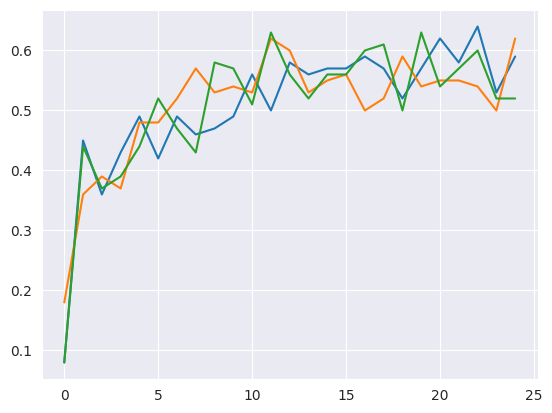

In [52]:
f = open("statistics/ortho_pretrain_wort_0.01.json")
ort_001 = json.load(f)
plt.plot(ort_001["train_accuracy"][::100])

f = open("statistics/ortho_pretrain_wort_0.03111111111111111.json")
ort_003 = json.load(f)
plt.plot(ort_003["train_accuracy"][::100])

f = open("statistics/ortho_pretrain_wort_0.07333333333333333.json")
ort_007 = json.load(f)
plt.plot(ort_007["train_accuracy"][::100])

##### Сравнение Ортогонализации и без нее

In [19]:
import json

f = open("statistics/baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/ortho_pretrain.json")
ortho_stat = json.load(f)

Text(0.5, 1.0, 'Accuracy')

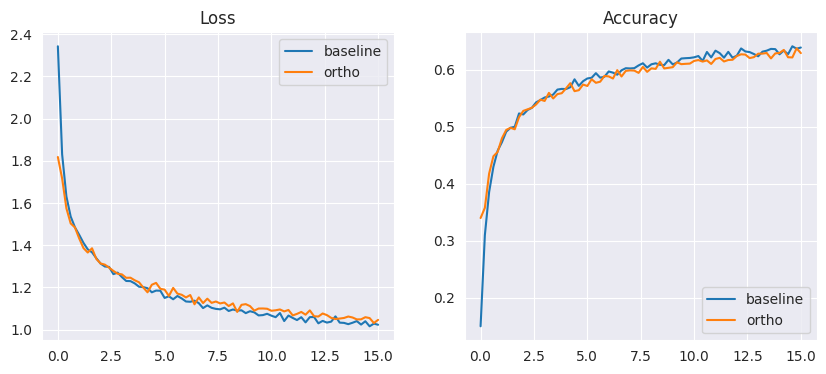

In [20]:
import matplotlib.pyplot as plt

gap = 100

fix, ax = plt.subplots(1, 2, figsize=(10, 4))

bl_mean_acc = [baseline_stat['train_accuracy'][0]]
bl_acc = 0.0
ort_mean_acc = [ortho_stat["train_accuracy"][0]]
ort_acc = 0.0
for i in range(1, len(ortho_stat['train_accuracy'])):
    ort_acc += ortho_stat['train_accuracy'][i]
    if i % gap == 0:
        ort_mean_acc.append(ort_acc / gap)
        ort_acc = 0.0
ort_mean_acc.append(ort_acc / (gap - 1))

for i in range(1, len(baseline_stat['train_accuracy'])):
    bl_acc += baseline_stat['train_accuracy'][i]
    if i % gap == 0:
        bl_mean_acc.append(bl_acc / gap)
        bl_acc = 0.0
bl_mean_acc.append(bl_acc / (gap - 1))

bl_mean_loss = [baseline_stat['train_loss'][0]]
bl_loss = 0.0
ort_mean_loss = [ortho_stat["train_loss"][0]]
ort_loss = 0.0
for i in range(1, len(ortho_stat['train_loss'])):
    ort_loss += ortho_stat['train_loss'][i]
    if i % gap == 0:
        ort_mean_loss.append(ort_loss / gap)
        ort_loss = 0.0
ort_mean_loss.append(ort_loss / (gap - 1))

for i in range(1, len(baseline_stat['train_loss'])):
    bl_loss += baseline_stat['train_loss'][i]
    if i % gap == 0:
        bl_mean_loss.append(bl_loss / gap)
        bl_loss = 0.0
bl_mean_loss.append(bl_loss / (gap - 1))


ax[0].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_loss, label="baseline")
ax[0].plot(ortho_stat['train_idx'][::100] + [15], ort_mean_loss, label="ortho")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_acc, label="baseline")
ax[1].plot(ortho_stat['train_idx'][::100] + [15], ort_mean_acc, label="ortho")
ax[1].legend()
ax[1].set_title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

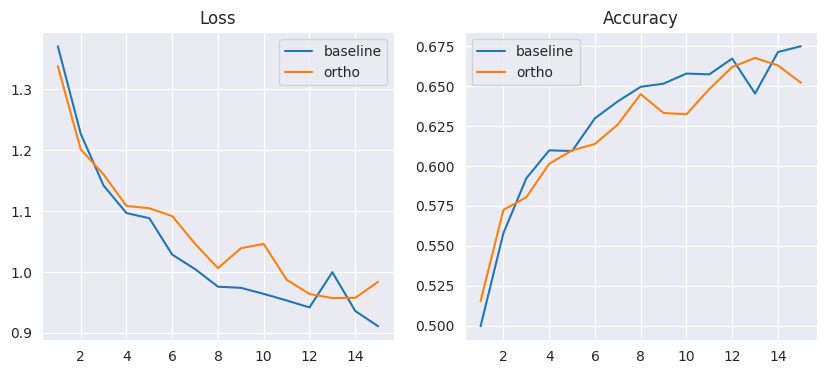

In [21]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(ortho_stat['test_idx'], ortho_stat["test_loss"], label="ortho")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(ortho_stat['test_idx'], ortho_stat["test_accuracy"], label="ortho")
ax[1].legend()
ax[1].set_title("Accuracy")

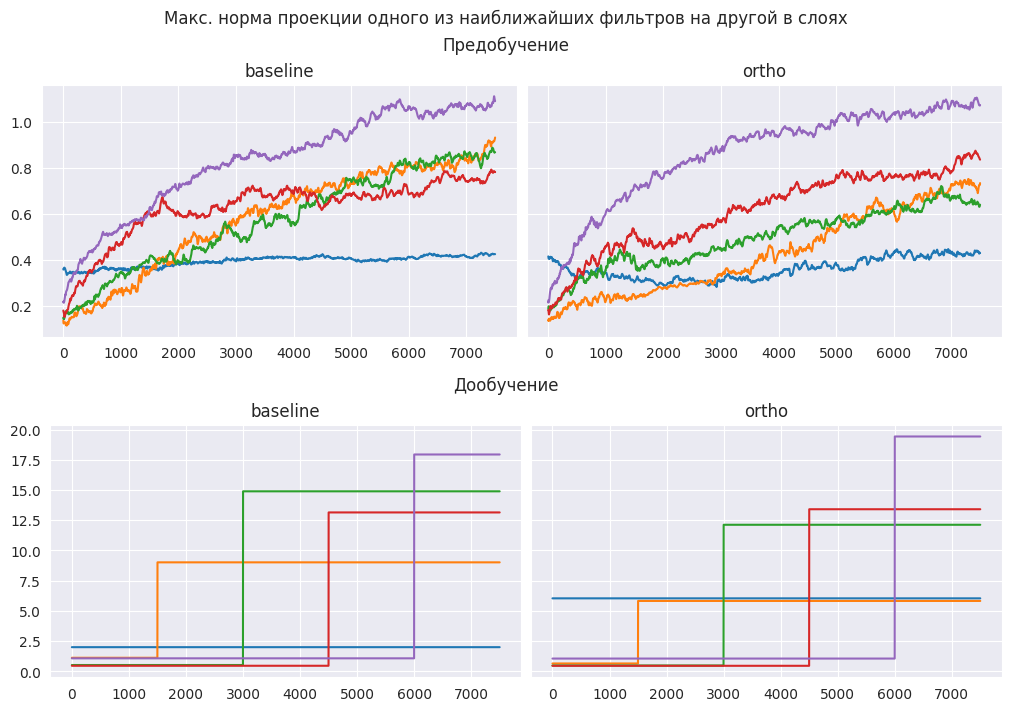

In [35]:
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
fig.suptitle('Макс. норма проекции одного из наиближайших фильтров на другой в слоях')
subfigs = fig.subfigures(2, 1)

subfigs[0].suptitle("Предобучение")
axs = subfigs[0].subplots(1, 2, sharey=True)
axs[0].set_title("baseline")
axs[1].set_title("ortho")
for i in range(5):
    axs[0].plot(max_proj_baseline[i][:7500], label=f"conv{i}" if i != 4 else "fc1")
    axs[1].plot(max_proj_ortho[i][:7500], label=f"conv{i}" if i != 4 else "fc1")

subfigs[1].suptitle("Дообучение")
axs = subfigs[1].subplots(1, 2, sharey=True)
axs[0].set_title("baseline")
axs[1].set_title("ortho")
for i in range(5):
    axs[0].plot(max_proj_baseline[i][7500:], label=f"conv{i}" if i != 4 else "fc1")
    axs[1].plot(max_proj_ortho[i][7500:], label=f"conv{i}" if i != 4 else "fc1")

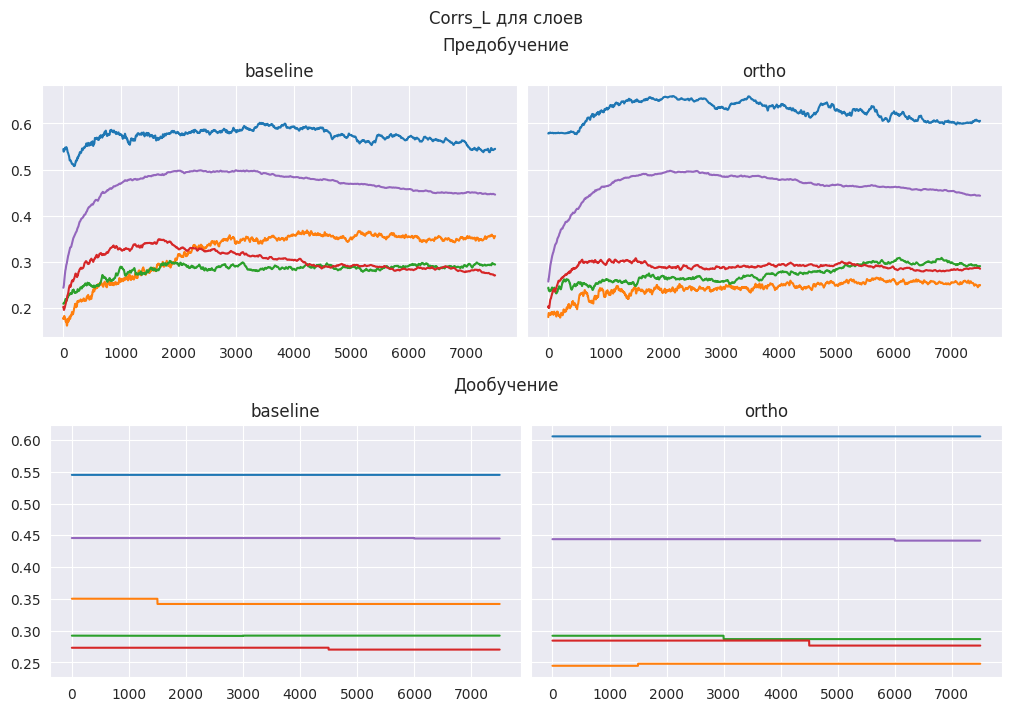

In [56]:
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
fig.suptitle('Corrs_L для слоев')
subfigs = fig.subfigures(2, 1)

subfigs[0].suptitle("Предобучение")
axs = subfigs[0].subplots(1, 2, sharey=True)
axs[0].set_title("baseline")
axs[1].set_title("ortho")
for i in range(5):
    axs[0].plot(corrs_l_baseline[i][:7500], label=f"conv{i}" if i != 4 else "fc1")
    axs[1].plot(corrs_l_ortho[i][:7500], label=f"conv{i}" if i != 4 else "fc1")
ax[0].plot(mean_corrs_baseline[:7500], label="среднее", linestyle="--")
ax[1].plot(mean_corrs_ortho[:7500], label="среднее", linestyle="--")

subfigs[1].suptitle("Дообучение")
axs = subfigs[1].subplots(1, 2, sharey=True)
axs[0].set_title("baseline")
axs[1].set_title("ortho")
for i in range(5):
    axs[0].plot(corrs_l_baseline[i][7500:], label=f"conv{i}" if i != 4 else "fc1")
    axs[1].plot(corrs_l_ortho[i][7500:], label=f"conv{i}" if i != 4 else "fc1")
ax[0].plot(mean_corrs_baseline[7500:], label="среднее", linestyle="--")
ax[1].plot(mean_corrs_ortho[7500:], label="среднее", linestyle="--")

##### PearsonCorrelation

In [29]:
model_pc = CNN6()
corr_reg = 0.01
device = torch.device("cpu")
device

device(type='cpu')

In [30]:
optimizer = optim.AdamW(model_pc.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs_pc = []
corrs_l_pc = [[] for _ in model_pc.conv_layers]
pearson_corr = correlation_loss(corr_reg, mean_corrs_pc, corrs_l_pc)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

pretrain_start = time()
train_stat_pc, test_stat_pc = train(model_pc, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=True, print_results=True,
                                                model_regularization=pearson_corr)
pretrain_end = time()

save_model(model_pc, f'pc_pretrain', test_loader, pretrain_end - pretrain_start, device=device)
save_statistics(f'pc_pretrain', train_stat_pc, test_stat_pc)

testing: 100%|██████████| 100/100 [00:01<00:00, 75.02it/s]


epoch #1: accuracy:  50.410%, loss:  1.41370.  19.76943s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 63.32it/s]


epoch #2: accuracy:  55.090%, loss:  1.30632.  23.50478s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 63.43it/s]


...

epoch #13: accuracy:  63.940%, loss:  1.04724.  22.98458s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 64.95it/s]


epoch #14: accuracy:  63.380%, loss:  1.06305.  22.57137s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 64.29it/s]


epoch #15: accuracy:  65.210%, loss:  1.00659.  22.60489s per epoch


In [31]:
pearson_corr_quant = count_mean_filter_correlation_model(mean_corrs_pc, corrs_l_pc)

model_quant_pc, train_quant_state_pc, test_quant_state_pc = quantization("pc", model_pc, 21, 25, True,
                                    model_update=pearson_corr_quant)

testing: 100%|██████████| 100/100 [00:01<00:00, 56.43it/s]


epoch #1: accuracy:  65.700%, loss:  0.97110.  20.36188s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 58.76it/s]


epoch #2: accuracy:  65.780%, loss:  0.96700.  20.40717s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 57.20it/s]


...

epoch #13: accuracy:  66.040%, loss:  0.96204.  16.95940s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.51it/s]


epoch #14: accuracy:  66.020%, loss:  0.96206.  17.10977s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 61.75it/s]


epoch #15: accuracy:  66.040%, loss:  0.96208.  16.11794s per epoch


###### Поиск значения параметров

In [9]:
step_epochs_exp = 5

lr_scale = 0.5
n_steps = 1
device = torch.device("cpu")
device

device(type='cpu')

In [10]:
for corr_reg in tqdm(np.logspace(-2, 0, 10)):
    model_pc = CNN6()
    optimizer = optim.AdamW(model_pc.parameters(), lr=2e-3, weight_decay=1e-5)

    mean_corrs_pc_exp = []
    corrs_l_pc_exp = [[] for _ in model_pc.conv_layers]
    pearson_corr = correlation_loss(corr_reg, mean_corrs_pc_exp, corrs_l_pc_exp)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs_exp, lr_scale)
    loss = nn.CrossEntropyLoss()

    pretrain_start = time()
    train_stat_pc_exp, test_stat_pc_exp = train(model_pc, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs_exp * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=False, print_results=False,
                                                model_regularization=pearson_corr)
    pretrain_end = time()

    save_model(model_pc, f'pc_pretrain_corr_reg_{corr_reg}', test_loader, pretrain_end - pretrain_start, device=device)
    save_statistics(f'pc_pretrain_corr_reg_{corr_reg}', train_stat_pc_exp, test_stat_pc_exp)

100%|██████████| 10/10 [18:53<00:00, 113.33s/it]


In [26]:
flst = ["pc_pretrain_corr_reg_0.016681005372000592.json",
"pc_pretrain_corr_reg_0.01.json",
"pc_pretrain_corr_reg_0.027825594022071243.json",
"pc_pretrain_corr_reg_0.046415888336127774.json",
"pc_pretrain_corr_reg_0.0774263682681127.json",
"pc_pretrain_corr_reg_0.1291549665014884.json",
"pc_pretrain_corr_reg_0.21544346900318834.json",
"pc_pretrain_corr_reg_0.3593813663804626.json",
"pc_pretrain_corr_reg_0.5994842503189409.json"]

In [14]:
import json
import matplotlib.pyplot as plt

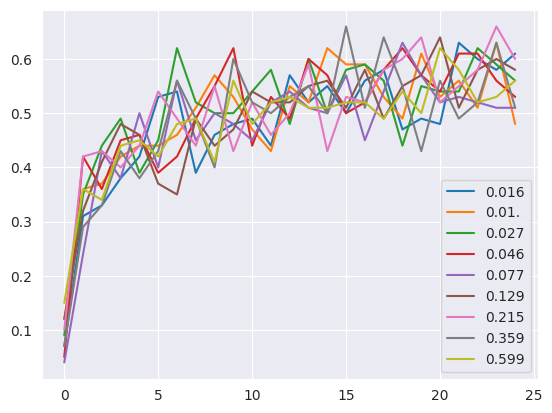

In [19]:
for fstr in flst:
    f = open("statistics/"+fstr)
    pc = json.load(f)
    plt.plot(pc["train_accuracy"][::100], label=fstr[21:26])
plt.legend()

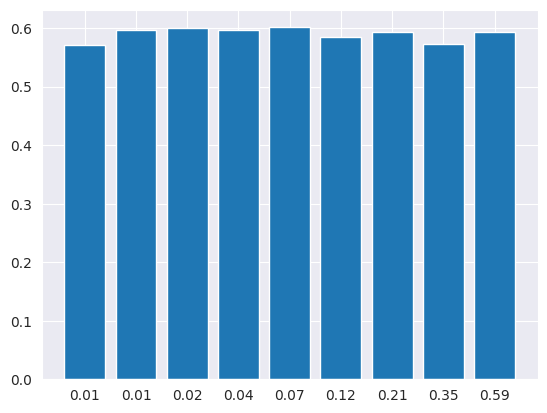

In [28]:
p = []

for fstr in flst:
    f = open("results/"+fstr)
    pc = json.load(f)
    p.append((fstr[21:25], pc["top1"]))

p.sort(key=lambda x: float(x[0]))

plt.bar(range(len(p)), [x[1] for x in p], align='center')
plt.xticks(range(len(p)), [x[0] for x in p])
print()

##### Сравнение PearsonCorrelation и без него

In [32]:
import json

f = open("statistics/baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/pc_pretrain.json")
pc_stat = json.load(f)

Text(0.5, 1.0, 'Accuracy')

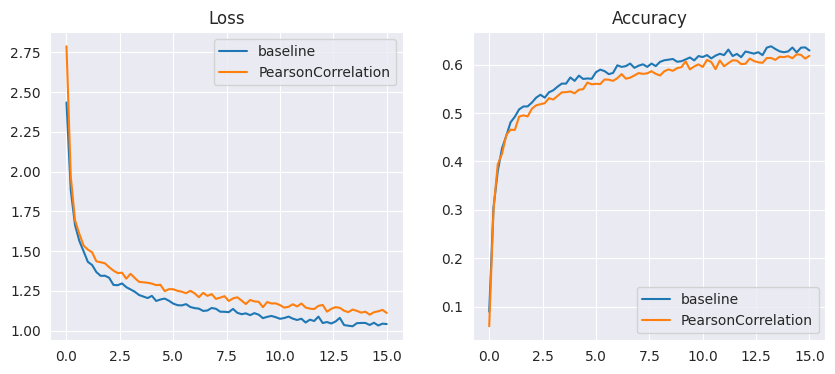

In [33]:
import matplotlib.pyplot as plt

gap = 100

fix, ax = plt.subplots(1, 2, figsize=(10, 4))

bl_mean_acc = [baseline_stat['train_accuracy'][0]]
bl_acc = 0.0
pc_mean_acc = [pc_stat["train_accuracy"][0]]
pc_acc = 0.0
for i in range(1, len(pc_stat['train_accuracy'])):
    pc_acc += pc_stat['train_accuracy'][i]
    if i % gap == 0:
        pc_mean_acc.append(pc_acc / gap)
        pc_acc = 0.0
pc_mean_acc.append(pc_acc / (gap - 1))

for i in range(1, len(baseline_stat['train_accuracy'])):
    bl_acc += baseline_stat['train_accuracy'][i]
    if i % gap == 0:
        bl_mean_acc.append(bl_acc / gap)
        bl_acc = 0.0
bl_mean_acc.append(bl_acc / (gap - 1))

bl_mean_loss = [baseline_stat['train_loss'][0]]
bl_loss = 0.0
pc_mean_loss = [pc_stat["train_loss"][0]]
pc_loss = 0.0
for i in range(1, len(pc_stat['train_loss'])):
    pc_loss += pc_stat['train_loss'][i]
    if i % gap == 0:
        pc_mean_loss.append(pc_loss / gap)
        pc_loss = 0.0
pc_mean_loss.append(pc_loss / (gap - 1))

for i in range(1, len(baseline_stat['train_loss'])):
    bl_loss += baseline_stat['train_loss'][i]
    if i % gap == 0:
        bl_mean_loss.append(bl_loss / gap)
        bl_loss = 0.0
bl_mean_loss.append(bl_loss / (gap - 1))


ax[0].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_loss, label="baseline")
ax[0].plot(pc_stat['train_idx'][::100] + [15], pc_mean_loss, label="PearsonCorrelation")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_acc, label="baseline")
ax[1].plot(pc_stat['train_idx'][::100] + [15], pc_mean_acc, label="PearsonCorrelation")
ax[1].legend()
ax[1].set_title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

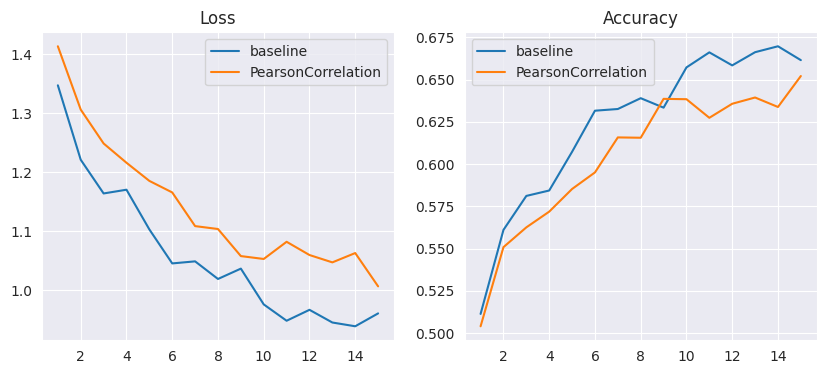

In [34]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(pc_stat['test_idx'], pc_stat["test_loss"], label="PearsonCorrelation")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(pc_stat['test_idx'], pc_stat["test_accuracy"], label="PearsonCorrelation")
ax[1].legend()
ax[1].set_title("Accuracy")


In [35]:
model_baseline = CNN6()
model_baseline.load_state_dict(torch.load("models/baseline_pretrain.pt", weights_only=True))
model_baseline.eval()
print()

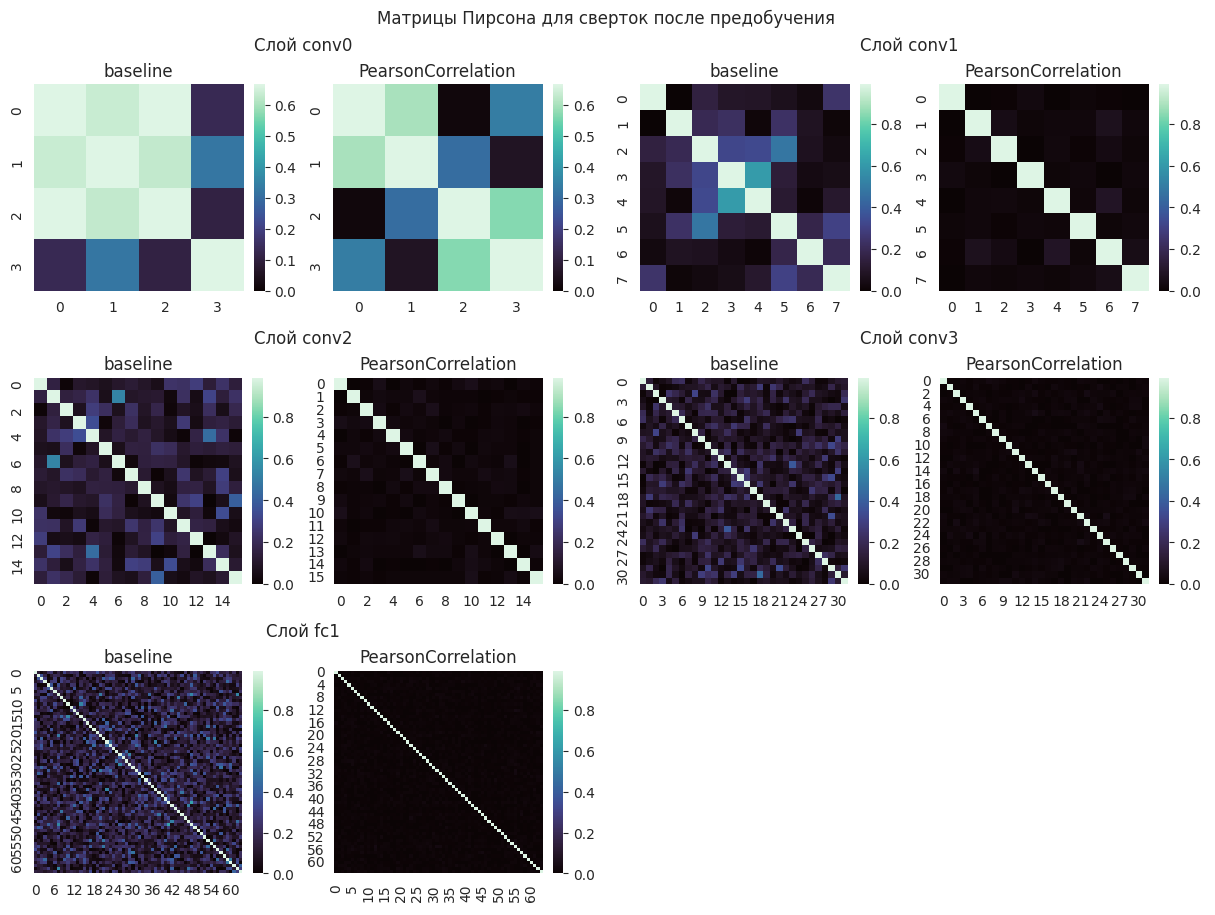

In [36]:
import seaborn as sns

fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_pc.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_pc = pearson_correlation_mat(model_pc.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_pc.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("PearsonCorrelation")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")

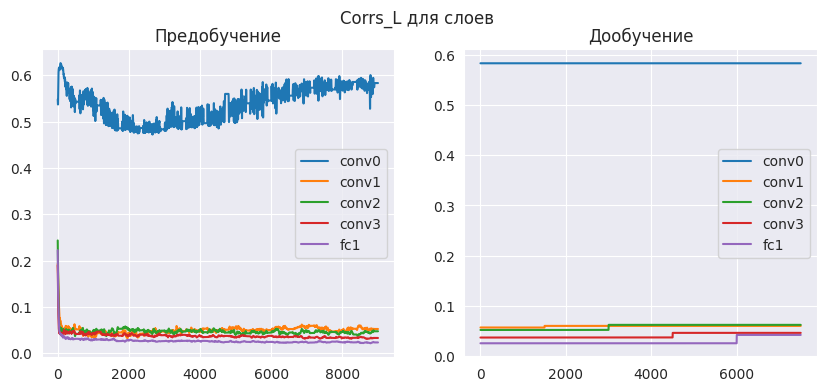

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Предобучение")
with torch.no_grad():
    for i, layer_name in enumerate(model_pc.conv_layers):
        axs[0].plot(corrs_l_pc[i][:9000], label=layer_name)
axs[0].legend()

axs[1].set_title("Дообучение")
with torch.no_grad():
    for i, layer_name in enumerate(model_pc.conv_layers):
        axs[1].plot(corrs_l_pc[i][9000:], label=layer_name)
axs[1].legend()

print()

#### FeaturesCovariance

In [9]:
model_f_cov = CNN6()
device = torch.device("cpu")
device

device(type='cpu')

In [10]:
step_epochs = 15

lr_scale = 0.5
n_steps = 1

feat_cov_reg = 1

In [14]:
optimizer = optim.AdamW(model_f_cov.parameters(), lr=2e-3, weight_decay=1e-5)

mean_corrs_f_cov = []
corrs_l_f_cov = [[] for _ in model_f_cov.conv_layers]
pearson_corr = count_mean_filter_correlation_model(mean_corrs_f_cov, corrs_l_f_cov)

fc_reg = feat_cov_loss(feat_cov_reg, [1])

scheduler = optim.lr_scheduler.StepLR(optimizer, step_epochs, lr_scale)
loss = nn.CrossEntropyLoss()

pretrain_start = time()
train_stat_f_cov, test_stat_f_cov = train(model_f_cov, optimizer, train_loader, test_loader, loss,
                                                n_epochs=step_epochs * n_steps, scheduler=scheduler,
                                                device=device, use_tqdm=True, print_results=True,
                                                model_regularization=fc_reg,
                                                model_update=[pearson_corr])
pretrain_end = time()

save_model(model_f_cov, f'f_cov_pretrain', test_loader, pretrain_end - pretrain_start, device=device)
save_statistics(f'f_cov_pretrain', train_stat_f_cov, test_stat_f_cov)

In [15]:
model_quant_f_cov, train_quant_state_f_cov, test_quant_state_f_cov = quantization("f_cov", model_f_cov, 21, 25, True,
                                    model_update=pearson_corr)

testing: 100%|██████████| 100/100 [00:01<00:00, 59.16it/s]


epoch #1: accuracy:  66.670%, loss:  0.94678.  19.55755s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 58.48it/s]


epoch #2: accuracy:  66.050%, loss:  0.96296.  19.49202s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 59.38it/s]


...

epoch #13: accuracy:  66.900%, loss:  0.93131.  16.92727s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 60.87it/s]


epoch #14: accuracy:  66.920%, loss:  0.93131.  16.63945s per epoch


testing: 100%|██████████| 100/100 [00:01<00:00, 61.38it/s]


epoch #15: accuracy:  66.940%, loss:  0.93132.  16.40570s per epoch


In [17]:
f = open("statistics/baseline_pretrain.json")
baseline_stat = json.load(f)

f = open("statistics/f_cov_pretrain.json")
f_cov_stat = json.load(f)

Text(0.5, 1.0, 'Accuracy')

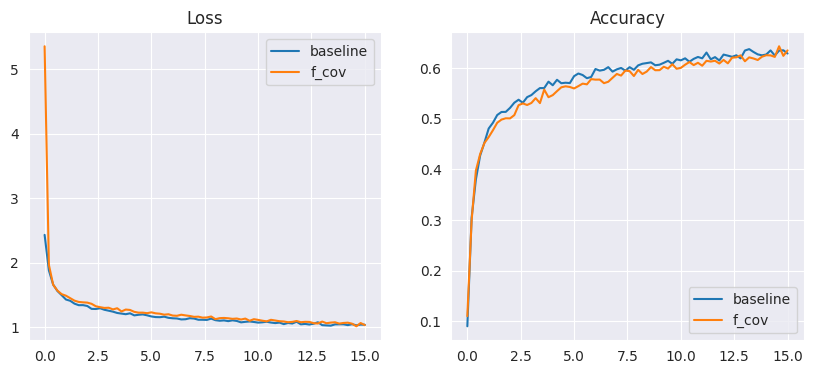

In [18]:
import matplotlib.pyplot as plt

gap = 100

fix, ax = plt.subplots(1, 2, figsize=(10, 4))

bl_mean_acc = [baseline_stat['train_accuracy'][0]]
bl_acc = 0.0
f_cov_mean_acc = [f_cov_stat["train_accuracy"][0]]
f_cov_acc = 0.0
for i in range(1, len(f_cov_stat['train_accuracy'])):
    f_cov_acc += f_cov_stat['train_accuracy'][i]
    if i % gap == 0:
        f_cov_mean_acc.append(f_cov_acc / gap)
        f_cov_acc = 0.0
f_cov_mean_acc.append(f_cov_acc / (gap - 1))

for i in range(1, len(baseline_stat['train_accuracy'])):
    bl_acc += baseline_stat['train_accuracy'][i]
    if i % gap == 0:
        bl_mean_acc.append(bl_acc / gap)
        bl_acc = 0.0
bl_mean_acc.append(bl_acc / (gap - 1))

bl_mean_loss = [baseline_stat['train_loss'][0]]
bl_loss = 0.0
f_cov_mean_loss = [f_cov_stat["train_loss"][0]]
f_cov_loss = 0.0
for i in range(1, len(f_cov_stat['train_loss'])):
    f_cov_loss += f_cov_stat['train_loss'][i]
    if i % gap == 0:
        f_cov_mean_loss.append(f_cov_loss / gap)
        f_cov_loss = 0.0
f_cov_mean_loss.append(f_cov_loss / (gap - 1))

for i in range(1, len(baseline_stat['train_loss'])):
    bl_loss += baseline_stat['train_loss'][i]
    if i % gap == 0:
        bl_mean_loss.append(bl_loss / gap)
        bl_loss = 0.0
bl_mean_loss.append(bl_loss / (gap - 1))


ax[0].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_loss, label="baseline")
ax[0].plot(f_cov_stat['train_idx'][::100] + [15], f_cov_mean_loss, label="f_cov")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['train_idx'][::100] + [15], bl_mean_acc, label="baseline")
ax[1].plot(f_cov_stat['train_idx'][::100] + [15], f_cov_mean_acc, label="f_cov")
ax[1].legend()
ax[1].set_title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

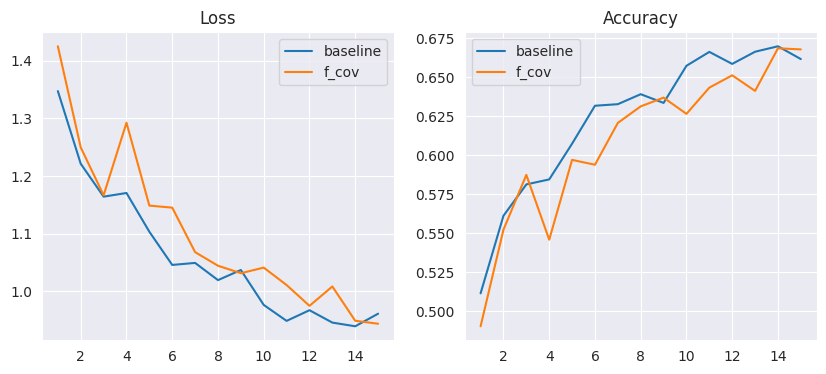

In [19]:
fix, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(baseline_stat['test_idx'], baseline_stat["test_loss"], label="baseline")
ax[0].plot(f_cov_stat['test_idx'], f_cov_stat["test_loss"], label="f_cov")
ax[0].legend()
ax[0].set_title("Loss")

ax[1].plot(baseline_stat['test_idx'], baseline_stat["test_accuracy"], label="baseline")
ax[1].plot(f_cov_stat['test_idx'], f_cov_stat["test_accuracy"], label="f_cov")
ax[1].legend()
ax[1].set_title("Accuracy")

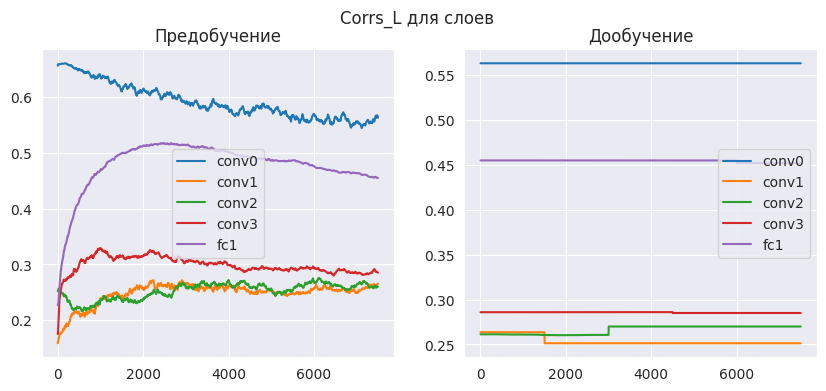

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Corrs_L для слоев")

axs[0].set_title("Предобучение")
with torch.no_grad():
    for i, layer_name in enumerate(model_f_cov.conv_layers):
        axs[0].plot(corrs_l_f_cov[i][:7500], label=layer_name)
axs[0].legend()

axs[1].set_title("Дообучение")
with torch.no_grad():
    for i, layer_name in enumerate(model_f_cov.conv_layers):
        axs[1].plot(corrs_l_f_cov[i][7500:], label=layer_name)
axs[1].legend()

print()

In [21]:
model_baseline = CNN6()
model_baseline.load_state_dict(torch.load("models/baseline_pretrain.pt", weights_only=True))
model_baseline.eval()
print()

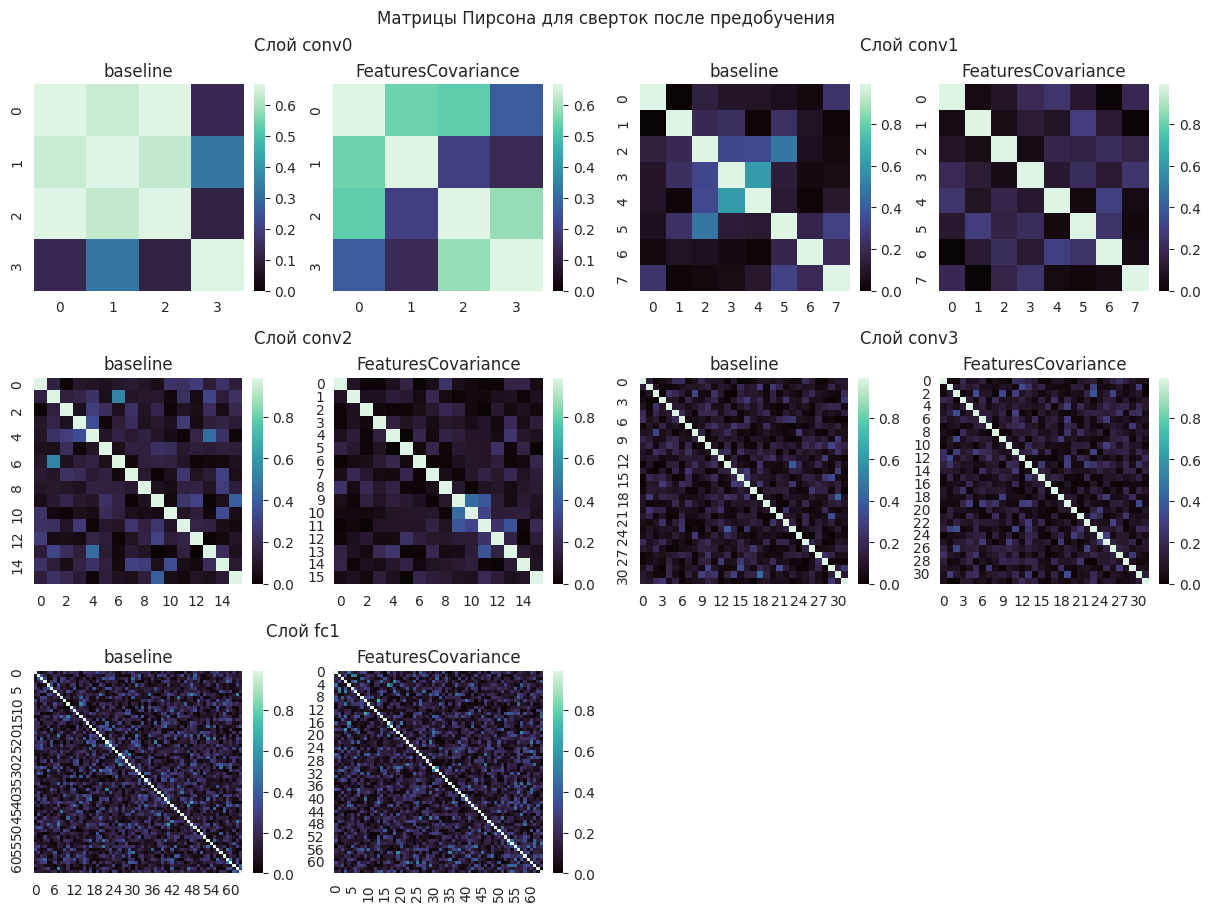

In [22]:
import seaborn as sns

fig = plt.figure(constrained_layout=True, figsize=(12, 9))
fig.suptitle('Матрицы Пирсона для сверток после предобучения')
subfigs = fig.subfigures(nrows=3, ncols=2)

with torch.no_grad():
    for i, layer in enumerate(model_f_cov.conv_layers):
        sup_ax = subfigs[i // 2][i % 2].subplots(1, 2)
        pm_bl = pearson_correlation_mat(model_baseline.get_submodule(f"{layer}").get_weight())
        pm_f_cov = pearson_correlation_mat(model_f_cov.get_submodule(f"{layer}").get_weight())
        sns.heatmap(pm_bl.abs(), cmap="mako", vmin=0, ax=sup_ax[0])
        sup_ax[0].set_title("baseline")
        sns.heatmap(pm_f_cov.abs(), cmap="mako", vmin=0, ax=sup_ax[1])
        sup_ax[1].set_title("FeaturesCovariance")
        subfigs[i // 2][i % 2].suptitle(f"Слой {layer}")